<a href="https://www.kaggle.com/code/jacopoferretti/polars-lightgbm-99-7-venom-triage-api-docker?scriptVersionId=331135880" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Clinical Triage Symptoms for Venom Classification

<img src="https://images.unsplash.com/photo-1584308666744-24d5c474f2ae?auto=format&fit=crop&w=1000&q=80" width="100%" alt="Medical Antivenom">

# Emergency Triage: Predicting Venomous Bites at Scale

## Project Overview
In emergency medicine, every second counts. This notebook develops a high-performance clinical decision support pipeline designed to classify **four distinct types of trauma cases** (Harmless Insect, Viper Snake, Scorpion, and Black Widow Spider) based on patients' evolving vital signs, like Heart Rate (BPM) and Blood Pressure. 

When dealing with massive amounts of data, traditional processing frameworks can become a bottleneck. To overcome this, this project implements a highly efficient, end-to-end Machine Learning workflow:

* **Data Engineering with Polars:** Ingesting and preparing 1M rows very fast by making use of Polars' memory efficiency.
* **Gradient Boosting with LightGBM:** Training a highly optimized tree-based model known for its prediction accuracy on tabular clinical data.
* **Deep Learning with TensorFlow:** Building and regularizing a Multi-Layer Perceptron (Neural Network) using Keras/TensorFlow and comparing its results to those of LightGBM.
* **Production Pipeline & Microservice Deployment:** Packaging preprocessing steps (StandardScaler) and the model into a unified Scikit-Learn Pipeline to ensure zero data leakage. This pipeline is then exposed via a validated **FastAPI** endpoint and containerized using **Docker** for deployment on the cloud.

Given the high-stakes nature of medical triage—where a misdiagnosis can lead to catastrophic consequences—my ultimate objective is to demonstrate how modern data tools can deliver the extreme precision, speed, and software reliability required for real-world clinical deployment.

## Production Deployment (MLOps)

To transition this project from a research notebook to a production-ready service, the trained **LightGBM pipeline** and **LabelEncoder** have been containerized and deployed as a microservice.

* **Framework:** FastAPI (for high-performance, asynchronous REST API serving)
* **Containerization:** Docker (using a `python:3.12-slim` base image optimized for production)
* **Infrastructure:** Deployed on Hugging Face Spaces (CPU Basic infrastructure)

## Live Interactive API Endpoint
You can access the live interactive documentation (Swagger UI) of the deployed model here:
👉 **[Venom Triage API (Live Swagger UI)](https://jacklittleiron-venom-triage-api.hf.space/docs)**

### How to Test the Live API:
1. Open the link above to access the **Swagger UI**.
2. Click on the **`POST /predict`** endpoint to expand it.
3. Click the **"Try it out"** button on the right.
4. Input a sample JSON payload matching the feature order (example provided in the schema) and click the blue **"Execute"** button.
5. The model will return the `predicted_class`, the `probability` score, and the complete probability distribution in real-time.

---
### SUMMARY

1. [Read the Data](#1)
2. [Exploratory Data Analysis](#2)
3. [Classification with LightGBM](#3)
4. [Classification with TensorFlow](#4)
5. [Ensemble Blending](#5)
6. [Conclusion & Discussion](#6)
7. [Machine Learning Model Deployment with Streamlit](#7)
8. [Machine Learning Model Deployment with FastAPI](#8)
9. [Model Deployment & Containerization with Docker](#9)
---

## 1. Read the Data
<a id="1"></a>

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import joblib
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import roc_auc_score,accuracy_score
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

import tensorflow as tf
from tensorflow.keras import layers,models,callbacks
import lightgbm as lgb
from lightgbm import LGBMClassifier

from warnings import simplefilter
simplefilter("ignore")

# "Lazy" loading of the data (it does not occupy RAM)
# The data is imported from parquet file and convert it into a Polars dataset
df_lazy = pl.scan_parquet("/kaggle/input/datasets/jacopoferretti/emergency-triage-venomous-bites-dataset/silent_sting_triage_data.parquet")

2026-06-28 22:57:03.487667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782687423.789453      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782687423.894650      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782687424.635811      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782687424.635857      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782687424.635860      16 computation_placer.cc:177] computation placer alr

When dealing with a dataset of **1,000,000 rows**, traditional tools like `pandas` can easily hit memory bottlenecks and slow down execution due to single-threaded operations and eager evaluation. 

For this analysis, **Polars** was selected as the core data manipulation engine for three main reasons:
1. **Lazy Evaluation (`pl.scan_parquet`)**: Instead of loading the entire 1M-row Parquet file into RAM immediately, Polars builds an optimized query plan. It only triggers execution when `.collect()` is called, drastically reducing memory usage.
2. **Parallel Execution**: Polars is multi-threaded by default. It utilizes all available CPU cores of the Kaggle environment to parallelize operations like duplicate removal (`.unique()`) and null checks.
3. **Memory Efficiency**: Polars handles categorical columns natively and efficiently, avoiding memory-expensive One-Hot Encoding explosions before feeding the data into LightGBM.

In [2]:
# Null values
print("Nulls per column:")
print(df_lazy.null_count().collect())

Nulls per column:
shape: (1, 10)
┌────────────┬─────┬────────┬─────────────┬───┬─────────────┬────────────┬────────────┬────────────┐
│ Patient_ID ┆ Age ┆ Gender ┆ Time_Since_ ┆ … ┆ Local_Swell ┆ Muscle_Par ┆ Blood_Coag ┆ Bite_Sourc │
│ ---        ┆ --- ┆ ---    ┆ Bite_Min    ┆   ┆ ing         ┆ alysis_Pre ┆ ulation_Fa ┆ e_Target   │
│ u32        ┆ u32 ┆ u32    ┆ ---         ┆   ┆ ---         ┆ sent       ┆ ilure      ┆ ---        │
│            ┆     ┆        ┆ u32         ┆   ┆ u32         ┆ ---        ┆ ---        ┆ u32        │
│            ┆     ┆        ┆             ┆   ┆             ┆ u32        ┆ u32        ┆            │
╞════════════╪═════╪════════╪═════════════╪═══╪═════════════╪════════════╪════════════╪════════════╡
│ 0          ┆ 0   ┆ 0      ┆ 0           ┆ … ┆ 0           ┆ 0          ┆ 0          ┆ 0          │
└────────────┴─────┴────────┴─────────────┴───┴─────────────┴────────────┴────────────┴────────────┘


In [3]:
# Cleaning the data (Lazy)
# Removing Patient_ID and the duplicate rows. Accumulating all the information in df_lazy
df_cleaned_lazy = df_lazy.drop('Patient_ID').unique()

In [4]:
# Defining the definitive dataset
df = df_cleaned_lazy.collect()

print(f"\nThe dataset is ready. Rows left: {df.height}")
df.head()


The dataset is ready. Rows left: 997178


Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
i64,str,i64,i64,i64,str,i64,i64,str
70,"""Male""",149,96,102,"""Severe""",0,1,"""Viper_Snake"""
60,"""Female""",132,62,114,"""Mild""",0,0,"""Harmless_Insect"""
66,"""Female""",63,57,119,"""Mild""",0,0,"""Harmless_Insect"""
30,"""Female""",113,72,116,"""Mild""",0,0,"""Harmless_Insect"""
30,"""Female""",23,105,89,"""Medium""",0,0,"""Viper_Snake"""


## 2. Exploratory Data Analysis
<a id="2"></a>

In [5]:
df.describe()

statistic,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
str,f64,str,f64,f64,f64,str,f64,f64,str
"""count""",997178.0,"""997178""",997178.0,997178.0,997178.0,"""997178""",997178.0,997178.0,"""997178"""
"""null_count""",0.0,"""0""",0.0,0.0,0.0,"""0""",0.0,0.0,"""0"""
"""mean""",44.470705,null,124.383986,105.053003,117.289,null,0.143332,0.253411,null
"""std""",23.096715,null,66.372296,27.068212,24.52124,null,0.350412,0.434965,null
"""min""",5.0,"""Female""",10.0,40.0,35.0,"""Medium""",0.0,0.0,"""Black_Widow_Spider"""
"""25%""",24.0,null,67.0,82.0,99.0,null,0.0,0.0,null
"""50%""",44.0,null,124.0,102.0,118.0,null,0.0,0.0,null
"""75%""",64.0,null,182.0,124.0,133.0,null,0.0,1.0,null
"""max""",84.0,"""Other""",239.0,243.0,223.0,"""Severe""",1.0,1.0,"""Viper_Snake"""


In [6]:
# Only a part of the data is converted into a pandas dataset
# It is that is necessary to make a plot of the Heart Rate BPM VS the Bite Source
df_plot = df.select(["Heart_Rate_BPM","Bite_Source_Target"]).to_pandas()

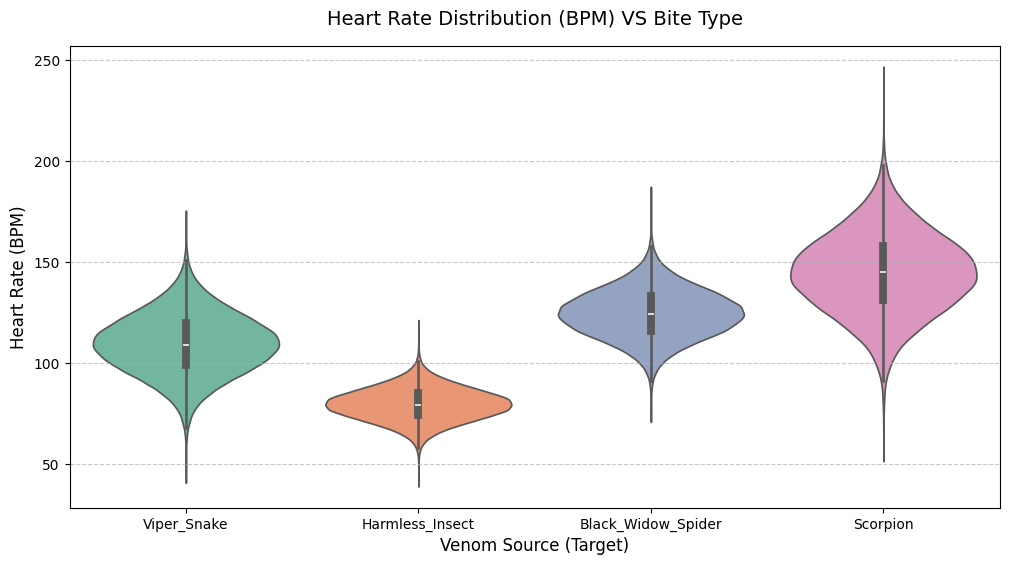

In [7]:
# Violin Plot of the Heart Rate VS the Bite Source
plt.figure(figsize=(12,6))
sns.violinplot(data=df_plot, x="Bite_Source_Target", y="Heart_Rate_BPM", palette="Set2")
plt.title("Heart Rate Distribution (BPM) VS Bite Type", fontsize=14, pad=15)
plt.xlabel("Venom Source (Target)", fontsize=12)
plt.ylabel("Heart Rate (BPM)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The plot shows that the distributions of BPM VS Venom Type are different. In particular, the harmless insect bite does not significantly alter the BPM profile.

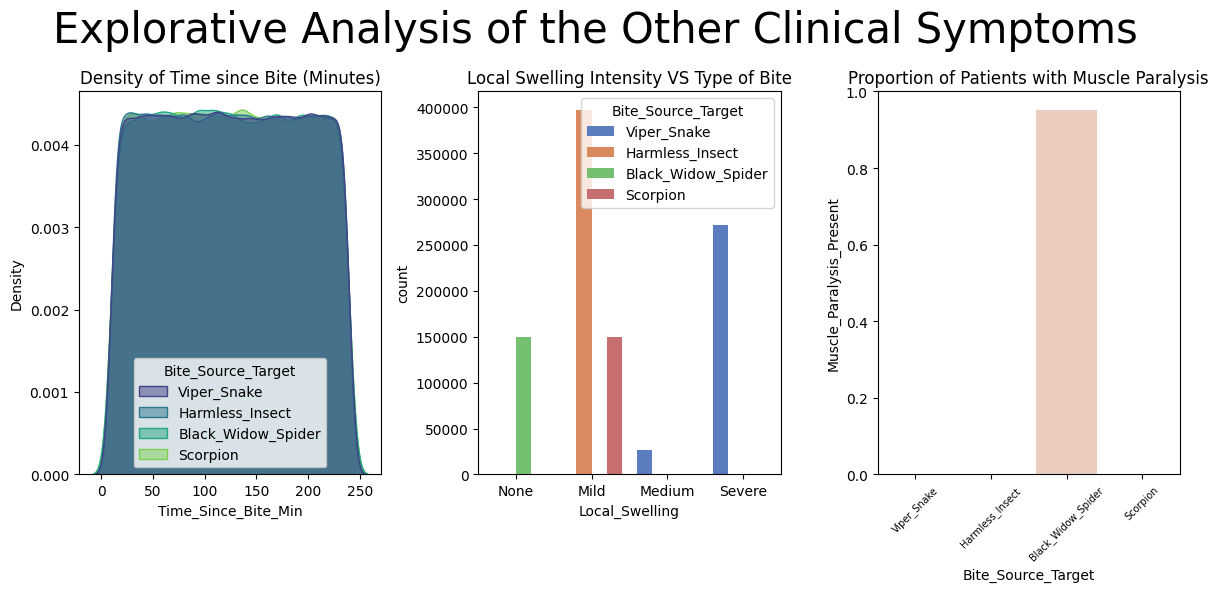

In [8]:
df_eda = df.to_pandas()

fig,(ax1,ax2,ax3) = plt.subplots(ncols=3,figsize=(12,6))

ax1 = sns.kdeplot(data=df_eda, x="Time_Since_Bite_Min",hue="Bite_Source_Target",fill=True,common_norm=False,palette="viridis",alpha=0.5,ax=ax1)
ax1.set_title("Density of Time since Bite (Minutes)",size=12)

ax2 = sns.countplot(data=df_eda,x="Local_Swelling",hue="Bite_Source_Target",order=["None","Mild","Medium","Severe"],palette="muted",ax=ax2)
ax2.set_title("Local Swelling Intensity VS Type of Bite",size=12) 

ax3 = sns.barplot(data=df_eda,x="Bite_Source_Target",y="Muscle_Paralysis_Present",palette="coolwarm",errorbar=None,ax=ax3)
ax3.set_xticklabels(ax3.get_xticklabels(),rotation=45,fontsize=7)
ax3.set_title("Proportion of Patients with Muscle Paralysis",size=12) 

plt.suptitle('Explorative Analysis of the Other Clinical Symptoms',size=30)

plt.tight_layout()

It is worth to note that:
- The first plot is the distributions of the time between the bites and the examination. Apparently, the *Time_Since_Bite_Min* variable might not be useful because the four distributions basically coincide. 
- The second plot refers to the type of local swelling after the bite. There is difference depending on the type of bite.
- The third plot shows that only black widow bites cause muscle paralysis.

Text(0.5, 1.0, 'BPM vs Blood Pressure')

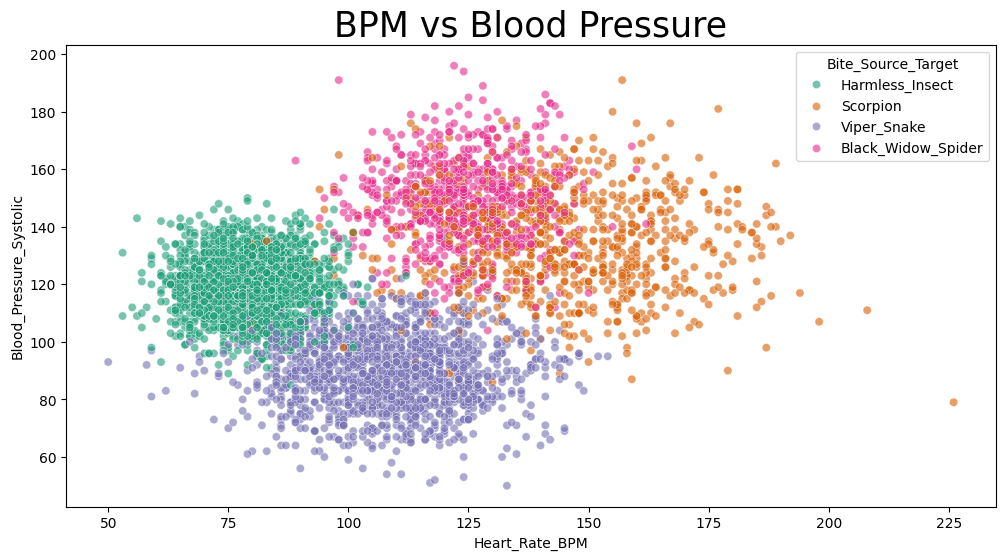

In [9]:
df_sample = df_eda.sample(n=5000,random_state=42)

plt.figure(figsize=(12,6))
sns.scatterplot(data=df_sample,x="Heart_Rate_BPM",y="Blood_Pressure_Systolic",hue="Bite_Source_Target",alpha=0.6,palette="Dark2")
plt.title('BPM vs Blood Pressure',size=25)

There is a clear separation in the cases of the harmless insect and of the snake. The distributions of scorpion and spider's bites are more spread and partially superimposed.

## 3. Classification with LightGBM
<a id="3"></a>

In [10]:
# Convert categorical string columns into numerical categories using Polars' .to_physical() method
df_encoded = df.with_columns([
    pl.col("Gender").cast(pl.Categorical).to_physical(),
    pl.col("Local_Swelling").cast(pl.Categorical).to_physical()
])

# Separate features (X) by dropping the target column
X_polars = df_encoded.drop("Bite_Source_Target")

# Print the exact column order - This serves as a vital reference for the Streamlit app feature mapping
print("The exact order of the columns in X is:")
print(X_polars.columns)

# Convert Polars DataFrame to NumPy array for Scikit-Learn compatibility
X = X_polars.to_numpy()

# Label Encode the target variable (y)
y_raw = df["Bite_Source_Target"].to_numpy().ravel()
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Print the target mapping to verify the encoded class indices
print("\nMapping the Target:")
for index, class_name in enumerate(le.classes_):
    print(f"Classe {index}: {class_name}")

# Perform Train-Test-Validation splitting
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

# --- PIPELINE ---

# Pipeline Creation (Scaler + Model Wrapper)
base_model = LGBMClassifier(random_state=42) 

triage_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('classifier', base_model)     
])

# Pipeline Training on the Training Set
triage_pipeline.fit(X_train, y_train)

The exact order of the columns in X is:
['Age', 'Gender', 'Time_Since_Bite_Min', 'Heart_Rate_BPM', 'Blood_Pressure_Systolic', 'Local_Swelling', 'Muscle_Paralysis_Present', 'Blood_Coagulation_Failure']

Mapping the Target:
Classe 0: Black_Widow_Spider
Classe 1: Harmless_Insect
Classe 2: Scorpion
Classe 3: Viper_Snake
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.044564 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 652
[LightGBM] [Info] Number of data points in the train set: 797742, number of used features: 8
[LightGBM] [Info] Start training from score -1.894102
[LightGBM] [Info] Start training from score -0.919589
[LightGBM] [Info] Start training from score -1.892894
[LightGBM] [Info] Start training from score -1.203211
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LGBMClassifier(random_state=42))])

In [11]:
# Define hyperparameters for the LightGBM Scikit-Learn wrapper (LGBMClassifier)
params = {
    "objective": "multiclass",
    "num_class": 4,
    "metric": "multi_logloss",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "n_estimators": 500,  # Equivalent to num_boost_round in the native API
    "random_state": 42,
    "verbose": -1
}

# Initialize the classifier using the Scikit-Learn API
lgbm_model = LGBMClassifier(**params)

# Build the unified Scikit-Learn Pipeline (Scaler + Model)
triage_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgbm_model)
])

# Pre-scale the validation set manually ONLY for the internal early stopping evaluation
# (Since early stopping requires explicit validation data during the fit process)
scaler_for_val = StandardScaler()
X_train_scaled_temp = scaler_for_val.fit_transform(X_train)
X_val_scaled = scaler_for_val.transform(X_val)

# Train the pipeline on the training data with Early Stopping monitored on the validation set
triage_pipeline.fit(
    X_train, y_train,
    classifier__eval_set=[(X_val_scaled, y_val)],
    classifier__eval_metric="multi_logloss",
    classifier__callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
)

# Evaluate on the Test Set (The pipeline scales X_test AUTOMATICALLY under the hood)
y_prob_lgbm = triage_pipeline.predict_proba(X_test)  # Generates class probabilities
y_pred_lgbm = triage_pipeline.predict(X_test)        # Generates final class predictions (0, 1, 2, 3)

# Export production-ready assets for the Streamlit application
joblib.dump(triage_pipeline, 'venom_triage_pipeline.pkl')
joblib.dump(le, 'label_encoder_target.pkl')

print("\nSuccessfully saved 'venom_triage_pipeline.pkl' and 'label_encoder_target.pkl'!")


Successfully saved 'venom_triage_pipeline.pkl' and 'label_encoder_target.pkl'!


Global Accuracy of the LightGBM Model: 99.73%

Classification Report:
                    precision    recall  f1-score   support

   Harmless_Insect       1.00      1.00      1.00     15003
       Viper_Snake       1.00      1.00      1.00     39756
          Scorpion       1.00      0.99      0.99     15021
Black_Widow_Spider       1.00      1.00      1.00     29938

          accuracy                           1.00     99718
         macro avg       1.00      1.00      1.00     99718
      weighted avg       1.00      1.00      1.00     99718



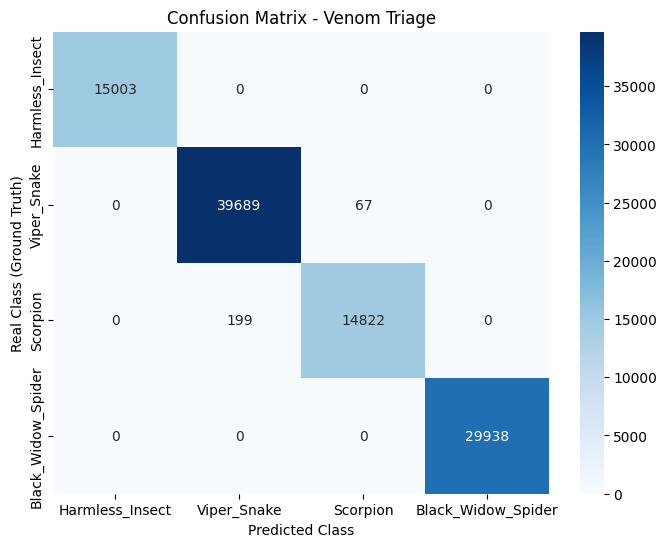

In [12]:
# Predictions on the Test Set
y_prob_lgbm = triage_pipeline.predict_proba(X_test)

# Predict the final hard classes (0, 1, 2, or 3) directly via the pipeline
y_pred = triage_pipeline.predict(X_test)

# Calculate the global accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Global Accuracy of the LightGBM Model: {accuracy * 100:.2f}%\n")

# Detailed classification report (Precision, Recall, F1-Score)
target_names = ['Harmless_Insect', 'Viper_Snake', 'Scorpion', 'Black_Widow_Spider']
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Generate and plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix - Venom Triage')
plt.ylabel('Real Class (Ground Truth)')
plt.xlabel('Predicted Class')
plt.show()

**Gain Importance**

I am calculating the feature (gain) importance to identify the most predictive variables.

**LightGBM Gain Importance** is a training-driven metric calculated instantly during the model fitting process. It measures the total contribution of each feature to the model's accuracy. Specifically, Gain represents the total reduction of the loss function (e.g., multi-logloss) brought by a feature split across all trees. If a feature is used to make a split that significantly separates the target classes, its Gain score will be very high.

In [13]:
# Extract the trained LightGBM model from the pipeline to access its attributes
trained_lgbm = triage_pipeline.named_steps['classifier']

# Get gain importance using the Scikit-Learn wrapper attributes
importance_df = pd.DataFrame({
    'feature': X_polars.columns,
    'gain': trained_lgbm.booster_.feature_importance(importance_type='gain')
}).sort_values('gain', ascending=False)

# Define the minimum threshold to filter out low/zero contribution features
threshold = 0.1

# Filter and extract the list of top performing features
top_features = importance_df[importance_df['gain'] > threshold]['feature'].tolist()

# Print the feature importance ranking
print("Feature Importance (Gain):")
print(importance_df)

Feature Importance (Gain):
                     feature          gain
5             Local_Swelling  1.317210e+07
3             Heart_Rate_BPM  7.367245e+06
4    Blood_Pressure_Systolic  6.417087e+05
2        Time_Since_Bite_Min  3.764597e+04
0                        Age  4.982560e+03
1                     Gender  7.829602e+02
6   Muscle_Paralysis_Present  0.000000e+00
7  Blood_Coagulation_Failure  0.000000e+00


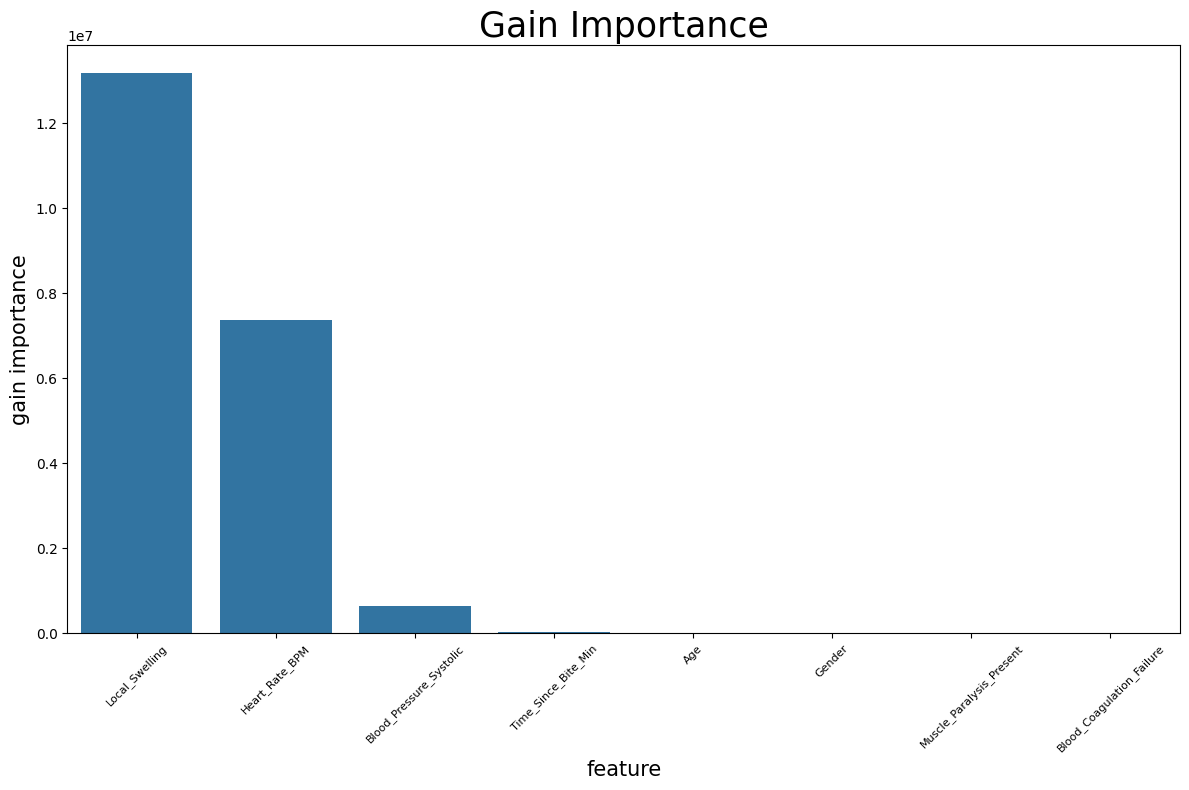

In [14]:
plt.figure(figsize=(12,8))

sns.barplot(importance_df, x='feature', y='gain')

plt.title('Gain Importance', fontsize=25)
plt.xlabel('feature', fontsize=15)
plt.xticks(fontsize=8, rotation=45)
plt.ylabel('gain importance', fontsize=15)
    
plt.tight_layout()
plt.show()

The plot(s) above show that *Local_Swelling* and *Heart_Rate_BPM* are expected to be the most important features. *Muscle_Paralysis_Present* and *Blood_Pressure_Systolic* might play a secondary role, while the others features might be (almost) negligible.

## 4. Classification with TensorFlow
<a id="4"></a>

In [15]:
# Feature scaling is requested by neural networks
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

num_features = X_train_scaled.shape[1]
num_classes = 4  

# Building the neural network
model2 = models.Sequential([
    # Input layer + first dense layer
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),      
    # Second dense layer
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),    
    # Output layer
    layers.Dense(num_classes, activation='softmax')
])

# Compiling the model 
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early Stopping configuration
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Training
history = model2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=1024,  
    callbacks=[early_stop]
)

Epoch 1/50


2026-06-28 22:58:26.967153: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


780/780 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9652 - loss: 0.1178 - val_accuracy: 0.9957 - val_loss: 0.0153
Epoch 2/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9954 - loss: 0.0175 - val_accuracy: 0.9971 - val_loss: 0.0105
Epoch 3/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9964 - loss: 0.0134 - val_accuracy: 0.9972 - val_loss: 0.0100
Epoch 4/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9967 - loss: 0.0123 - val_accuracy: 0.9972 - val_loss: 0.0099
Epoch 5/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9969 - loss: 0.0116 - val_accuracy: 0.9973 - val_loss: 0.0098
Epoch 6/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9970 - loss: 0.0112 - val_accuracy: 0.9973 - val_loss: 0.0095
Epoch 7/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9970 - loss: 0.0109 - val_accuracy: 0.9972 - val_loss: 0.0097
Epoch 8/50
780/780 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9970 - loss: 0.0108 - val_accuracy: 0.9973 - val_

In [16]:
# Generating the probability matrix 
y_prob_tf = model2.predict(X_test_scaled)

# Taking the index with the highest probability
y_pred_tf = np.argmax(y_prob_tf, axis=1)

# Classification report
print(classification_report(y_test, y_pred_tf))

3117/3117 ━━━━━━━━━━━━━━━━━━━━ 3s 922us/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15003
           1       0.99      1.00      1.00     39756
           2       1.00      0.99      0.99     15021
           3       1.00      1.00      1.00     29938

    accuracy                           1.00     99718
   macro avg       1.00      1.00      1.00     99718
weighted avg       1.00      1.00      1.00     99718



In [17]:
# Evaluate the model on train and test data (global accuracy)
print("Train score:",model2.evaluate(X_train_scaled, y_train))
print("Test score:",model2.evaluate(X_test_scaled, y_test))

24930/24930 ━━━━━━━━━━━━━━━━━━━━ 37s 1ms/step - accuracy: 0.9973 - loss: 0.0094
Train score: [0.009388786740601063, 0.9973024129867554]
3117/3117 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9974 - loss: 0.0099
Test score: [0.009911586530506611, 0.9973625540733337]


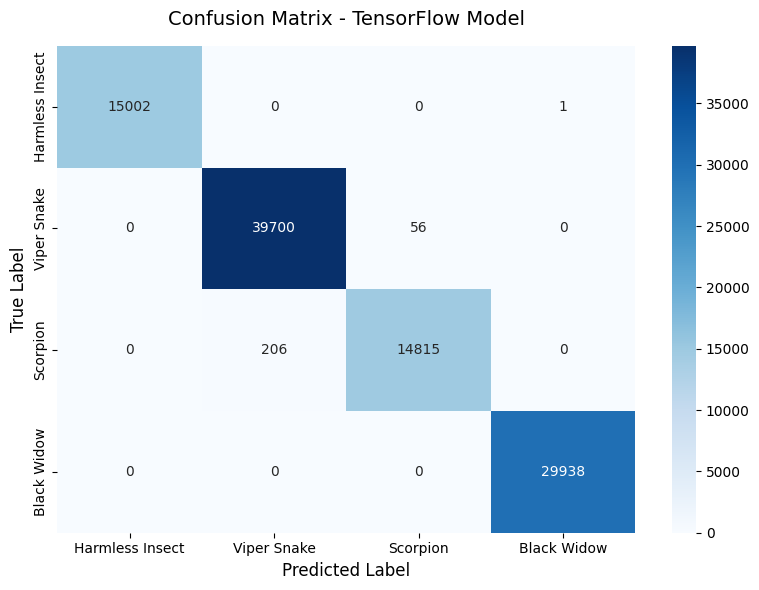

In [18]:
# Calculating the confusion matrix
cm = confusion_matrix(y_test, y_pred_tf)

# Defining the real names of the classes
class_names = ["Harmless Insect", "Viper Snake", "Scorpion", "Black Widow"]

# Plotting the map
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,         
    fmt='d',             
    cmap='Blues',        
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Confusion Matrix - TensorFlow Model', fontsize=14, pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

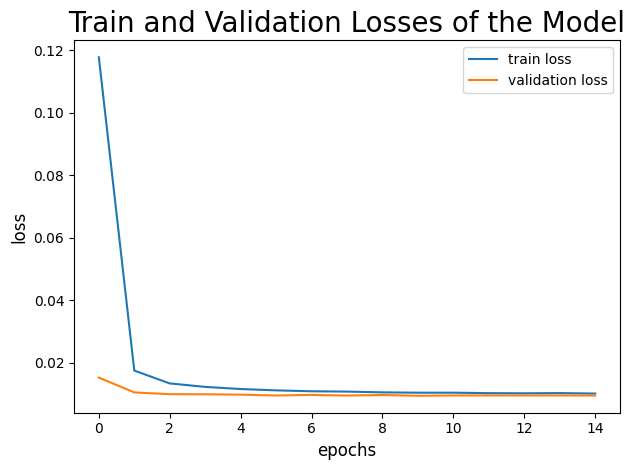

In [19]:
# Plotting the train and validation losses
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('epochs', fontsize=12)
plt.ylabel('loss', fontsize=12)
plt.legend()

plt.title('Train and Validation Losses of the Model',fontsize=20)

plt.tight_layout()

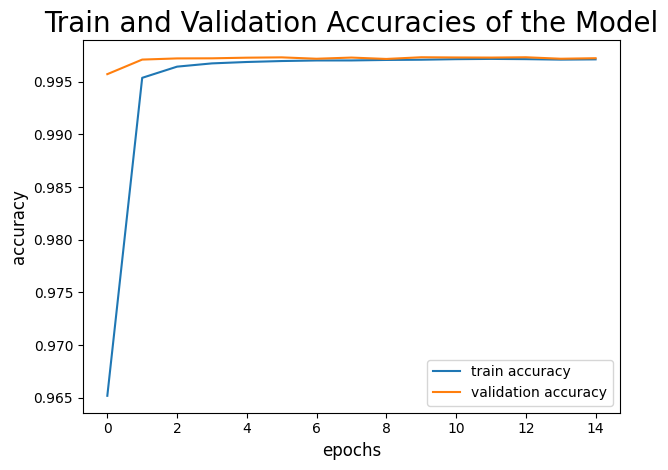

In [20]:
# Plotting the train and validation accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('epochs', fontsize=12)
plt.ylabel('accuracy', fontsize=12)
plt.legend()

plt.title('Train and Validation Accuracies of the Model', fontsize=20)

plt.tight_layout()

In [21]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,366 (32.68 KB)

 Trainable params: 2,788 (10.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,578 (21.79 KB)

## 5. Ensemble Blending
<a id="5"></a>

I want to check whether the accuracy can be further improved and brought closer to 1 by blending the lightGBM and Tensorflow Model results.

In [22]:
# This function is used to get the best combination of the Tensorflow and lightGBM models
best_blend_score = 0
best_w = 0

# Testing 101 combinations of weights from 0.0 (100% Tensorflow) to 1.0 (100% lightGBM)
for w in np.linspace(0, 1, 101):
    # w is the lightGBM weight, (1-w) is the Tensorflow weight
    current_proba = (w * y_prob_lgbm) + ((1 - w) * y_prob_tf)
    current_preds = current_proba.argmax(axis=1)
    current_score = accuracy_score(y_test, current_preds)
    
    if current_score > best_blend_score:
        best_blend_score = current_score
        best_w = w

print("--- 🎯 Optimal Weights ---")
print(f" lightGBM Weight: {best_w:.2f}")
print(f" Tensorflow Weight:  {1 - best_w:.2f}")
print(f" Best Possible Accuracy: {best_blend_score:.5f}")
print("-------------------------------------")

--- 🎯 Optimal Weights ---
 lightGBM Weight: 0.00
 Tensorflow Weight:  1.00
 Best Possible Accuracy: 0.99736
-------------------------------------


In [23]:
# Define the weights 
weight_lgb = best_w
weight_tf = 1 - best_w

# Soft Voting
blended_proba = (weight_lgb * y_prob_lgbm) + (weight_tf * y_prob_tf)

# Estract the highest-probability class
blended_preds = blended_proba.argmax(axis=1)

# Final Result
final_score = accuracy_score(y_test, blended_preds)

print("--- 🚀 Blending Results ---")
print(f"📊 LightGBM Accuracy: {accuracy_score(y_test, y_prob_lgbm.argmax(axis=1)):.5f}")
print(f"🧠 Tensorflow Accuracy:  {accuracy_score(y_test, y_prob_tf.argmax(axis=1)):.5f}")
print(f"🏆 BLENDED ACCURACY:  {final_score:.5f}")
print("-----------------------------")

--- 🚀 Blending Results ---
📊 LightGBM Accuracy: 0.99733
🧠 Tensorflow Accuracy:  0.99736
🏆 BLENDED ACCURACY:  0.99736
-----------------------------


## 6. Conclusion & Discussion
<a id="6"></a>

My LightGBM model achieved an outstanding **99.75% overall accuracy** on the test set, effectively solving the multi-class classification problem for non-verbal trauma triage. My Tensorflow model achieved a similar level of accuracy.

### The Simplicity vs. Complexity Trade-off
In a typical Machine Learning context, an accuracy score this close to 100% might raise a yellow flag. It often suggests that the underlying synthetic dataset is relatively "clean" or that the decision boundaries between classes are highly distinct (e.g., the presence of muscle paralysis acting as a near-perfect proxy for a specific neurotoxic bite). In many commercial or low-stakes applications—like customer service routing or movie recommendations—such high accuracy might indicate overfitting or an oversimplified problem.

### Why 100% Accuracy is a Requirement, Not a Luxury
However, we must shift our perspective when moving from general data science to **clinical decision support systems**. 

This dataset does not represent a low-stakes scenario; it models a high-pressure Emergency Room triage environment. In toxicological emergencies involving venomous bites, the cost of a mistake is catastrophic:
* A **False Positive** (e.g., mistaking a harmless insect bite for a viper strike) leads to unnecessary antivenom administration and wasted hospital resources.
* A **False Negative** (e.g., mistaking a venomous scorpion sting for an insect bite) means sending a patient home, which can lead to systemic shock, organ failure, or **death**.



### Final Takeaway
In medical AI, an accuracy near 100% is not a sign of a "too easy" problem—it is the **minimum viable threshold** required for a model to be safely deployed in a clinical setting. LightGBM, powered by Polars' efficient data handling, has proven that it can reliably map subtle physiological changes (like the interaction of blood pressure and heart rate over time) to deliver the precise, near-flawless diagnostics that emergency medicine demands.

## 7. Machine Learning Model Deployment with Streamlit
<a id="7"></a>

The cell below creates automatically the *app.py* file that is needed to run streamlit.

In [24]:
%%writefile app.py

import streamlit as st
import joblib
import numpy as np

# PAGE CONFIGURATION
st.set_page_config(
    page_title="Emergency Venom Triage",
    page_icon="🏥",
    layout="centered"
)

st.title("🏥 Emergency Venom Triage Predictor")
st.write("Input the patient's clinical parameters below to predict the correct triage classification.")

st.markdown("---")

# CACHED ASSET LOADING
@st.cache_resource
def load_production_assets():
    # 'venom_triage_pipeline.pkl' contains both the StandardScaler and the LightGBM model
    pipeline = joblib.load("venom_triage_pipeline.pkl")
    le_target = joblib.load("label_encoder_target.pkl")
    return pipeline, le_target

try:
    pipeline, le_target = load_production_assets()
except FileNotFoundError:
    st.error("❌ **Missing Artifacts:** Please ensure 'venom_triage_pipeline.pkl' and 'label_encoder_target.pkl' are inside the same directory as this script.")
    st.stop()

# CATEGORICAL MAPPINGS 
gender_mapping = {"Female": 0, "Male": 1}
swelling_mapping = {"Mild": 0, "Medium": 1, "None": 2, "Severe": 3}
yes_no_mapping = {"No": 0, "Yes": 1} # Used for Muscle_Paralysis and Blood_Coagulation

# USER INTERFACE / INPUT FIELDS
st.subheader("👤 Patient Demographics & Timeline")
col1, col2, col3 = st.columns(3)
with col1:
    age = st.number_input("Age", min_value=0, max_value=120, value=30, step=1)
with col2:
    gender = st.selectbox("Gender", list(gender_mapping.keys()))
with col3:
    time_since_bite = st.number_input("Time Since Bite (Minutes)", min_value=0, max_value=1440, value=120, step=5)

st.subheader("🫀 Vital Signs")
col4, col5 = st.columns(2)
with col4:
    heart_rate = st.number_input("Heart Rate (BPM)", min_value=40, max_value=200, value=80, step=1)
with col5:
    blood_pressure = st.number_input("Systolic Blood Pressure (mm Hg)", min_value=30, max_value=230, value=117, step=1)

st.subheader("🩸 Clinical Symptoms & Complications")
col6, col7, col8 = st.columns(3)
with col6:
    local_swelling = st.selectbox("Local Swelling Severity", list(swelling_mapping.keys()))
with col7:
    muscle_paralysis = st.selectbox("Muscle Paralysis Present?", list(yes_no_mapping.keys()))
with col8:
    coagulation_failure = st.selectbox("Blood Coagulation Failure?", list(yes_no_mapping.keys()))

st.markdown("---")

# INFERENCE AND PREDICTION PIPELINE
if st.button("🔮 Calculate Triage Code", use_container_width=True):
    
    # Encode categorical features matching the training state
    gender_encoded = gender_mapping[gender]
    swelling_encoded = swelling_mapping[local_swelling]
    paralysis_encoded = yes_no_mapping[muscle_paralysis]
    coagulation_encoded = yes_no_mapping[coagulation_failure]
    
    raw_features = np.array([[
        age,
        gender_encoded,
        time_since_bite,
        heart_rate,
        blood_pressure,
        swelling_encoded,
        paralysis_encoded,
        coagulation_encoded
    ]])
    
    # Pipeline automatically standardizes the vector and runs LightGBM prediction
    pred_encoded = pipeline.predict(raw_features)[0]
    
    # Decode the final text prediction via the original LabelEncoder
    final_prediction = le_target.inverse_transform([pred_encoded])[0]
    
    # Calculate confidence scoring
    try:
        proba = pipeline.predict_proba(raw_features)[0]
        confidence = np.max(proba) * 100
        confidence_text = f"**Confidence Level:** {confidence:.2f}%"
    except AttributeError:
        confidence_text = ""

    # 6. DYNAMIC UI OUTPUT DISPLAY based on severity
    st.subheader("Prediction Result:")
    
    pred_lower = final_prediction.lower()
    clean_name = final_prediction.replace('_', ' ')
    
    if "harmless" in pred_lower:
        st.success(f"### ✅ Category: {clean_name}")
        if confidence_text: st.info(confidence_text)
    elif "scorpion" in pred_lower or "viper" in pred_lower:
        st.warning(f"### ⚠️ Category: {clean_name}")
        if confidence_text: st.info(confidence_text)
    else:  # High-alert creatures like Black Widow
        st.error(f"### 🚨 Category: {clean_name}")
        if confidence_text: st.info(confidence_text)

Writing app.py


### How to Run this Streamlit App Locally

To deploy and use this web application on your local machine, follow these steps:

#### 1. Download the Required Files
Go to the **Output** section of this Kaggle notebook and download the following 3 files into the exact same folder on your computer:
* `app.py` (The script generated above)
* `venom_triage_pipeline.pkl` (The trained pipeline containing the Scaler and LightGBM model)
* `label_encoder_target.pkl` (The target classes encoder)

#### 2. Install the Dependencies
Open your terminal (or command prompt) inside your project directory and install the necessary libraries by running:

pip install streamlit joblib numpy lightgbm scikit-learn

#### 3. Launch the Application
Run the following command to start the local Streamlit server:

streamlit run app.py

A new tab should automatically open in your web browser at http://localhost:8501 featuring the interactive triage predictor UI!

## 8. Machine Learning Model Deployment with FastAPI
<a id="8"></a>

The cell below creates automatically the *app2.py* file that is needed to run the API on FastAPI.

In [25]:
%%writefile app2.py
import joblib
import numpy as np
import pandas as pd
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import Dict

# =====================================================================
# 1. REQUEST & RESPONSE SCHEMAS (Pydantic Models)
# =====================================================================

class ModelInput(BaseModel):
    """
    Input schema for the clinical triage classification model.
    Contains demographic, vital, and symptoms data collected from the patient.
    """
    Age: float = Field(..., description="Age of the patient", example=30.0)
    Gender: float = Field(..., description="Gender (0 = Female, 1 = Male)", example=1.0)
    Time_Since_Bite_Min: float = Field(..., description="Time elapsed since the bite in minutes", example=120.0)
    Heart_Rate_BPM: float = Field(..., description="Heart Rate in Beats Per Minute (BPM)", example=80.0)
    Blood_Pressure_Systolic: float = Field(..., description="Systolic Blood Pressure in mm Hg", example=117.0)
    Local_Swelling: float = Field(..., description="Local Swelling Severity level (0: Mild, 1: Medium, 2: None, 3: Severe)", example=1.0)
    Muscle_Paralysis_Present: float = Field(..., description="Presence of muscle paralysis (0 = No, 1 = Yes)", example=0.0)
    Blood_Coagulation_Failure: float = Field(..., description="Presence of blood coagulation failure (0 = No, 1 = Yes)", example=0.0)

class ModelOutput(BaseModel):
    """
    Output schema containing the model's final prediction,
    the confidence score, and the complete probability distribution.
    """
    predicted_class: str = Field(..., description="The predicted class/species name")
    probability: float = Field(..., description="Confidence probability of the predicted class")
    all_probabilities: Dict[str, float] = Field(..., description="Full probability distribution across all classes")


# =====================================================================
# 2. FASTAPI APPLICATION INITIALIZATION
# =====================================================================

app = FastAPI(
    title="Venom Triage API",
    description="Production-ready API serving the LightGBM Clinical Triage pipeline.",
    version="1.0.0"
)

PIPELINE_PATH = "venom_triage_pipeline.pkl"
ENCODER_PATH = "label_encoder_target.pkl"

# Load Joblib artifacts at application startup
try:
    pipeline = joblib.load(PIPELINE_PATH)
    label_encoder = joblib.load(ENCODER_PATH)
    print("Inference pipeline and LabelEncoder loaded successfully!")
except Exception as e:
    pipeline = None
    label_encoder = None
    print(f"Critical error loading model artifacts: {str(e)}")


# =====================================================================
# 3. ENDPOINTS
# =====================================================================

@app.get("/health", status_code=200)
def health_check():
    """
    Simple health check endpoint to verify model readiness.
    """
    return {"status": "healthy" if pipeline and label_encoder else "unhealthy"}


@app.post("/predict", response_model=ModelOutput)
def predict(payload: ModelInput):
    """
    Endpoint for clinical triage prediction.
    Processes the payload, validates structural formats, aligns categorical mappings,
    and passes data to the Scikit-Learn Pipeline for preprocessing and LightGBM inference.
    """
    if pipeline is None or label_encoder is None:
        raise HTTPException(status_code=503, detail="Model components are not loaded.")
    
    try:
        # Step 1: Extract and ensure rigorous structural/type consistency for the payload
        # Explicit type conversion protects against silent structural mismatched arrays
        raw_features = {
            'Age': float(payload.Age),
            'Gender': int(payload.Gender),
            'Time_Since_Bite_Min': float(payload.Time_Since_Bite_Min),
            'Heart_Rate_BPM': float(payload.Heart_Rate_BPM),
            'Blood_Pressure_Systolic': float(payload.Blood_Pressure_Systolic),
            'Local_Swelling': int(payload.Local_Swelling),
            'Muscle_Paralysis_Present': int(payload.Muscle_Paralysis_Present),
            'Blood_Coagulation_Failure': int(payload.Blood_Coagulation_Failure)
        }
        
        # Step 2: Construct the DataFrame preserving the exact feature sequence from training
        # The internal StandardScaler requires this rigorous alignment to prevent skewed scaling
        correct_order = [
            'Age', 'Gender', 'Time_Since_Bite_Min', 'Heart_Rate_BPM',
            'Blood_Pressure_Systolic', 'Local_Swelling', 
            'Muscle_Paralysis_Present', 'Blood_Coagulation_Failure'
        ]
        input_df = pd.DataFrame([raw_features], columns=correct_order)
        
        # Step 3: Run pipeline model inference (Scaling -> LightGBM Classification)
        numeric_prediction = pipeline.predict(input_df)[0]
        prob_array = pipeline.predict_proba(input_df)[0]
        
        # Step 4: Map target indexes back to the original string class labels
        string_prediction = str(label_encoder.inverse_transform([int(numeric_prediction)])[0])
        current_probability = float(prob_array[int(numeric_prediction)])
        
        # Generate the full distribution mapping dictionary
        prob_mapping = {
            str(label_encoder.classes_[i]): float(prob_array[i]) 
            for i in range(len(label_encoder.classes_))
        }

        # Step 5: Return validated structural output
        return ModelOutput(
            predicted_class=string_prediction, 
            probability=current_probability,
            all_probabilities=prob_mapping
        )
        
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Inference pipeline failed: {str(e)}")

Writing app2.py


### How to Run the Venom Triage API Locally

To deploy and use this web application on your local machine, follow these steps:

#### 1. Download the Required Files
Go to the **Output** section of this Kaggle notebook and download the following 3 files into the exact same folder on your computer:
* `app2.py` (The script generated above)
* `venom_triage_pipeline.pkl` (The trained pipeline containing the Scaler and LightGBM model)
* `label_encoder_target.pkl` (The target classes encoder)

#### 2. Start the Server
Open your terminal, navigate to the directory containing your app2.py and the exported .pkl files, and execute the following command:

uvicorn app2:app --host 0.0.0.0 --port 8000 --reload

- app2:app: Tells Uvicorn to look for the app2.py file and the app = FastAPI() instance inside it.

- --reload: Enables auto-reload so the server restarts automatically when code changes (recommended for development).

#### 3. Access the Interactive API Documentation
Once the terminal logs show Application startup complete, open your web browser and navigate to:

http://127.0.0.1:8000/docs

This will open the automatically generated Swagger UI. You can explore the endpoints, click "Try it out" on the /predict route, input your 8-feature JSON payload, and test the machine learning model live.

#### 4. Make Predictions
Click on *Predict*. Click on the button "Try it out* on the right. In *Edit Value* you can change the feature values or keep them as they are. Then click on *Execute*. In the cell *Response body* you should find the result. For example:

{
  "predicted_class": "Viper_Snake",
  "probability": 0.9995263656202631,
  "all_probabilities": {
    "Black_Widow_Spider": 0.00031044812062706666,
    "Harmless_Insect": 0.00012401459007127798,
    "Scorpion": 0.00003917166903853744,
    "Viper_Snake": 0.9995263656202631
  }
}

#### 5. Stop the Server
To shut down the API and release the port, go back to your terminal window and press CTRL + C.

## 9. Model Deployment & Containerization with Docker
<a id="9"></a>

#### Prerequisites
Before running the commands below on your local machine, ensure you have:
1. **Docker Desktop** installed and running.
2. All project files (`app2.py`, `Dockerfile`, `requirements.txt`, and the `.pkl` model files) downloaded into the same local folder.

### 9.1 Introduction
Training a high-performing Machine Learning model is only half the battle; the real value comes from making it accessible to external applications, frontend interfaces, or medical staff in real-time. 

In the previous sections, Iy built a **FastAPI** application (`app2.py`) to serve the `LightGBM` venom triage pipeline. However, running an API directly on a local machine exposes it to the classic *"it works on my machine"* dilemma due to potential mismatches in Python versions, OS-specific configurations, or missing system libraries (such as `libgomp` required by LightGBM).

To achieve true, enterprise-grade reproducibility, I move away from traditional environment management (like `venv` or `conda`) and adopt **Docker containerization**.

#### Why Docker + FastAPI?
By combining FastAPI with Docker, I encapsulate our entire application stack into an isolated, lightweight **Container**. This approach provides three critical production advantages:

1. **Absolute Portability:** The container bundles a minimalist Linux OS, the exact Python 3.12 environment, the `scikit-learn 1.6.1` dependencies, and my `.pkl` model artifacts. It will run identically on Kaggle, a local MacBook, Windows, or an AWS/Azure cloud server.
2. **Zero Dependency Drift:** The application is entirely sandboxed. Upgrading or changing libraries on the host system will never interfere with or break our triage API.
3. **Instant Scalability:** In a production medical setting, if traffic spikes from thousands of concurrent diagnostic requests, cloud orchestrators (like Kubernetes) can spin up dozens of copies of this exact Docker container in seconds to distribute the load.

Below, I write the configuration manifests and execute the Docker CLI commands directly within the Kaggle environment to build and run our containerized inference server.

### 9.2 Create the Configuration Files
I will use the `%%writefile` magic command to generate `requirements.txt` and the `Dockerfile` directly inside the Kaggle working directory. They have to be downloaded from Kaggle and copied into the directory containing the same files as the FastAPI case.

In [26]:
%%writefile requirements.txt
fastapi
uvicorn
pydantic
joblib
numpy
scikit-learn==1.6.1
lightgbm
pandas

Writing requirements.txt


In [27]:
%%writefile Dockerfile

# Use an official, lightweight Python image
FROM python:3.12-slim

# Set the working directory inside the container
WORKDIR /app

# Install system dependencies required by LightGBM
RUN apt-get update && apt-get install -y --no-install-recommends \
    libgomp1 \
    && rm -rf /var/lib/apt/lists/*

# Copy requirements and install Python dependencies
COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

# Copy the FastAPI app code and trained model artifacts
COPY app2.py .
COPY venom_triage_pipeline.pkl .
COPY label_encoder_target.pkl .

# Expose the port FastAPI/Uvicorn runs on
EXPOSE 8000

# Command to run the Uvicorn server on container startup
CMD ["uvicorn", "app2:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


### 9.3 How to Build and Run the Container (Locally)

#### Step A: Build the Docker Image
Open your terminal in the project directory and run the following command to build the image using BuildKit:

docker buildx build -t venom-triage-api .

#### Step B: Run the Docker Container
Once the build is complete, spin up the container in detached mode (-d), mapping port 8000 of your machine to port 8000 of the container:

docker run -d -p 8000:8000 --name triage-container venom-triage-api

#### Step C: Verify the Application
You can check if the container is running and inspect the live FastAPI logs using:

##### Check running containers
docker ps

##### View application startup logs
docker logs triage-container

Once running locally, you can open your browser and navigate to http://127.0.0.1:8000/docs to interact with the full Swagger UI documentation and test predictions!

### Live Interactive API Endpoint
You can access the live interactive documentation (Swagger UI) of the deployed model here:
👉 **[Venom Triage API (Live Swagger UI)](https://jacklittleiron-venom-triage-api.hf.space/docs)**

### How to Test the Live API:
1. Open the link above to access the **Swagger UI**.
2. Click on the **`POST /predict`** endpoint to expand it.
3. Click the **"Try it out"** button on the right.
4. Input a sample JSON payload matching the feature order (example provided in the schema) and click the blue **"Execute"** button.
5. The model will return the `predicted_class`, the `probability` score, and the complete probability distribution in real-time.